<a href="https://colab.research.google.com/github/odamasceno/Calculo-Numerico/blob/main/Atividade_pr%C3%A1tica_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#Bibliotecas Necessárias
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#função para truncamento
def truncamento(n, x):
  return math.trunc((10**n)*x)/ 10**n


## 3 - Parte A

,Valor de Ref (x),Casas (n),Truncado,Arredondado,Ea Trunc,Ea Arred,Er Trunc,Er Arred,E% Trunc,E% Arred
0,3.141593,0,3.0000,3.0000,0.141593,0.141593,4.507034e-02,4.507034e-02,4.507034,4.507034
1,3.141593,1,3.1000,3.1000,0.041593,0.041593,1.323935e-02,1.323935e-02,1.323935,1.323935
2,3.141593,2,3.1400,3.1400,0.001593,0.001593,5.069562e-04,5.069562e-04,0.050696,0.050696
3,3.141593,3,3.1410,3.1420,0.000593,0.000407,1.886464e-04,1.296635e-04,0.018865,0.012966
4,3.141593,4,3.1415,3.1416,0.000093,0.000007,2.949141e-05,2.339578e-06,0.002949,0.000234
5,98.765430,0,98.0000,99.0000,0.765430,0.234570,7.749979e-03,2.375021e-03,0.774998,0.237502
6,98.765430,1,98.7000,98.8000,0.065430,0.034570,6.624788e-04,3.500213e-04,0.066248,0.035002
7,98.765430,2,98.7600,98.7700,0.005430,0.004570,5.497875e-05,4.627125e-05,0.005498,0.004627
8,98.765430,3,98.7650,98.7650,0.000430,0.000430,4.353750e-06,4.353750e-06,0.000435,0.000435
9,98.765430,4,98.7654,98.7654,0.000030,0.000030,3.037500e-07,3.037500e-07,0.000030,0.000030


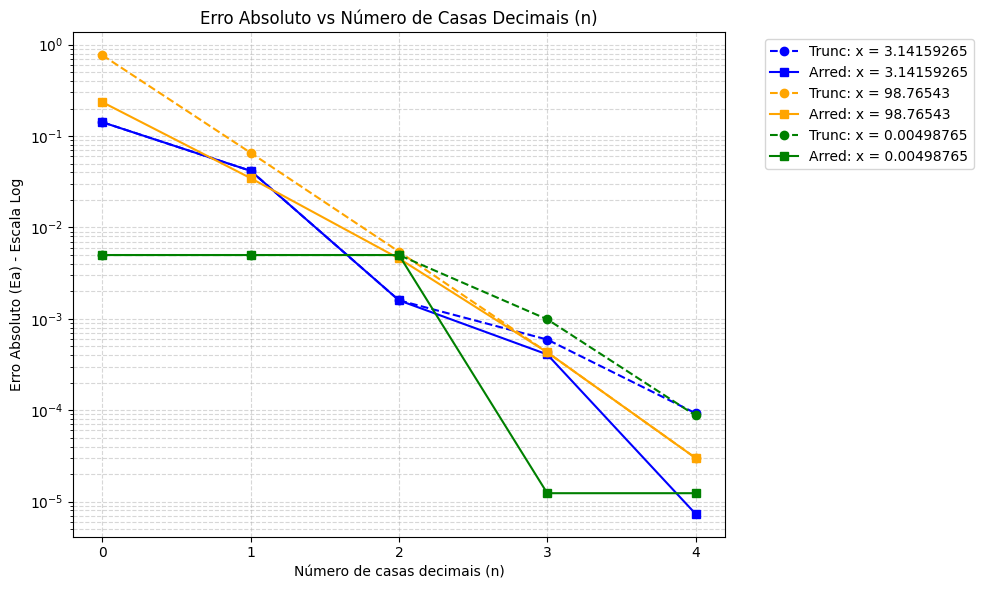

In [11]:
x = [3.14159265, 98.76543, 0.00498765]
n = [0,1,2,3,4]

linhas_tabela = []

for xi in x:
  for ni in n:
    #calculando a aproximação por truncamento e por arredondamento em cada X, com cada N
    xtrunc = truncamento(ni,xi)
    xarrend = round(xi,ni)

    #calculo do erro absoluto:
    erroAbsTrunc = abs(xi - xtrunc)
    erroAbsArrend = abs(xi - xarrend)

    #calculo do erro Relativo:
    erroRelTrunc = erroAbsTrunc/abs(xi)
    erroRelArrend = erroAbsArrend/abs(xi)

    #Erros percentuais
    percentTrunc = 100*erroRelTrunc
    percentArrend = 100*erroRelArrend

    linhas_tabela.append({
        'Valor de Ref (x)': xi,
        'Casas (n)': ni,
        'Truncado': xtrunc,
        'Arredondado': xarrend,
        'Ea Trunc': erroAbsTrunc,
        'Ea Arred': erroAbsArrend,
        'Er Trunc': erroRelTrunc,
        'Er Arred': erroRelArrend,
        'E% Trunc': percentTrunc,
        'E% Arred': percentArrend
    })

# Criando e exibindo a tabela
tabela_df = pd.DataFrame(linhas_tabela)
display(tabela_df)

plt.figure(figsize=(10, 6))



# Cores para diferenciar cada valor de x
cores = ['blue', 'orange', 'green']

for i, xi in enumerate(x):
    dados_x = tabela_df[tabela_df['Valor de Ref (x)'] == xi]
    plt.plot(dados_x['Casas (n)'], dados_x['Ea Trunc'],
             linestyle='--', marker='o', color=cores[i],
             label=f'Trunc: x = {xi}')

    plt.plot(dados_x['Casas (n)'], dados_x['Ea Arred'],
             linestyle='-', marker='s', color=cores[i],
             label=f'Arred: x = {xi}')

# Configurando o gráfico
plt.yscale('log')
plt.xlabel('Número de casas decimais (n)')
plt.ylabel('Erro Absoluto (Ea) - Escala Log')
plt.title('Erro Absoluto vs Número de Casas Decimais (n)')
plt.xticks(n)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Exibir o gráfico
plt.tight_layout()
plt.show()


### **Resposta 5**
Sim, arredondar sempre gera um erro menor ou igual ao truncamento. Ao analisar os resultados do grafico e da tabela, é possível observar que os valores obtidos pelo arredondamento são sempre inferiores ou iguais ao do truncamento, isso ocorre por conta da forma como a aproximação é efetuada em cada um dos casos

## 4 - Parte B

In [14]:
#Criação das Séries - Parte B1
s1 = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
s2 = np.round(s1)
s3 = np.trunc(s1) #n = 0, entao da pra usar a propria função

media_ref = np.mean(s1)
media_s2 = np.mean(s2)
media_s3 = np.mean(s3)

#Obtenção dos dados
def calc_dados(nome_serie, dados):
    media = np.mean(dados)
    minimo = np.min(dados)
    maximo = np.max(dados)
    amplitude = maximo - minimo

    desvio_padrao = np.std(dados, ddof=1)

    ea_media = abs(media_ref - media)
    er_media = ea_media / abs(media_ref)
    ep_media = 100 * er_media

    return {
        'Série': nome_serie,
        'Média': media,
        'Mínimo': minimo,
        'Máximo': maximo,
        'Amplitude': amplitude,
        'Desv-Padrão': desvio_padrao,
        'Ea (Média)': ea_media,
        'Er (Média)': er_media,
        'E% (Média)': ep_media
    }

<>:35: SyntaxWarning: invalid escape sequence '\%'
<>:35: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_1950/3064755791.py:35: SyntaxWarning: invalid escape sequence '\%'
  ax[1, 0].set_title('3. Erros Percentuais das Médias ($E_{\%}$)')


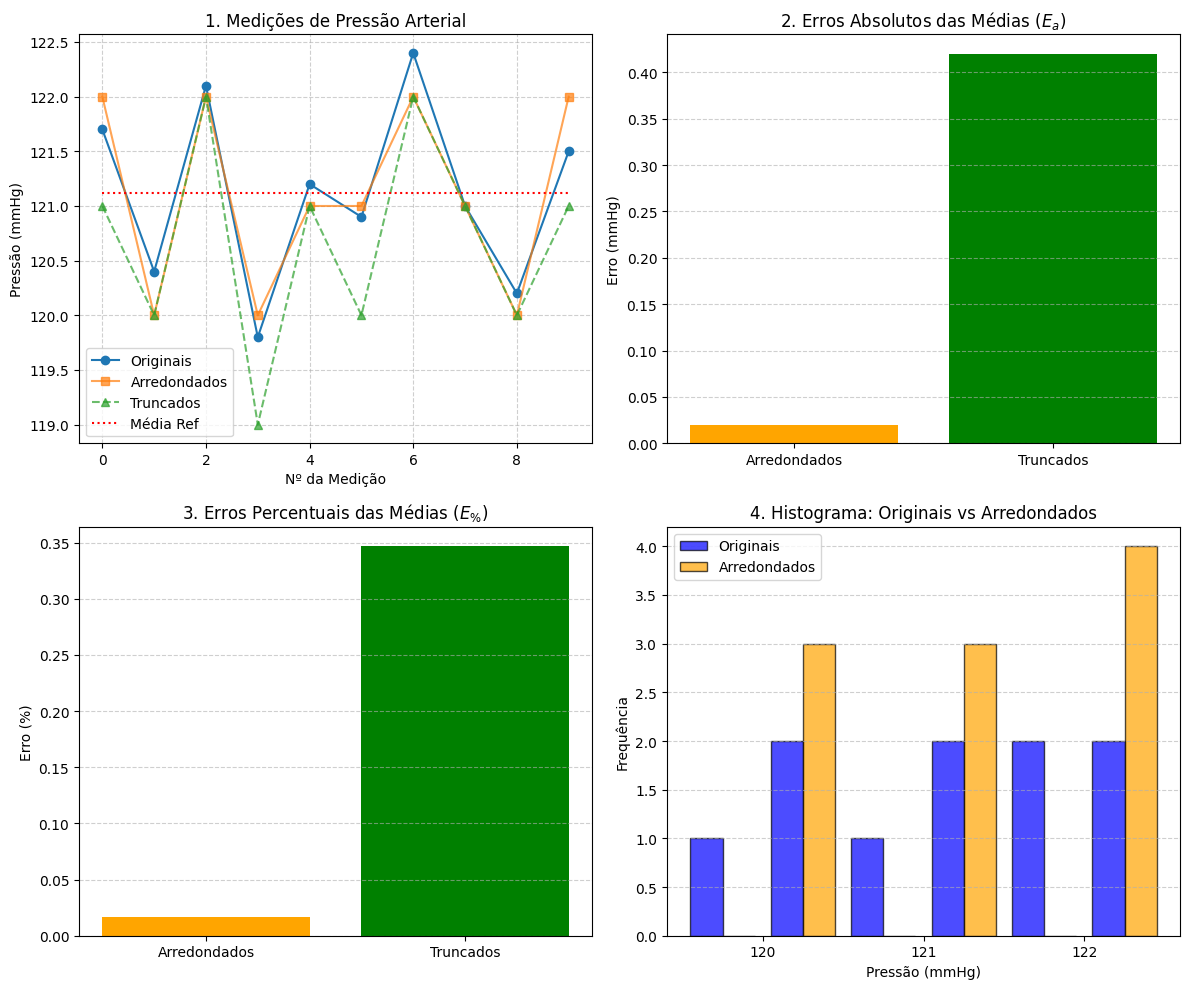

In [21]:
#Parte B2 - Graficos

media_ref_array = np.full(len(s1), media_ref)


ea_s2 = abs(media_ref - media_s2)
ea_s3 = abs(media_ref - media_s3)

ep_s2 = 100 * (ea_s2 / abs(media_ref))
ep_s3 = 100 * (ea_s3 / abs(media_ref))

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0, 0].plot(s1, marker='o', label='Originais')
ax[0, 0].plot(s2, marker='s', label='Arredondados', alpha=0.7)
ax[0, 0].plot(s3, marker='^', linestyle='--', label='Truncados', alpha=0.7)
ax[0, 0].plot(media_ref_array, color='red', linestyle=':', label='Média Ref')
ax[0, 0].set_title('1. Medições de Pressão Arterial')
ax[0, 0].set_xlabel('Nº da Medição')
ax[0, 0].set_ylabel('Pressão (mmHg)')
ax[0, 0].legend()
ax[0, 0].grid(True, linestyle='--', alpha=0.6)

#Gráfico de barras dos Erros Absolutos
labels = ['Arredondados', 'Truncados']
erros_abs = [ea_s2, ea_s3]
ax[0, 1].bar(labels, erros_abs, color=['orange', 'green'])
ax[0, 1].set_title('2. Erros Absolutos das Médias ($E_a$)')
ax[0, 1].set_ylabel('Erro (mmHg)')
ax[0, 1].grid(axis='y', linestyle='--', alpha=0.6)

#Gráfico de barras dos Erros Percentuais
erros_perc = [ep_s2, ep_s3]
ax[1, 0].bar(labels, erros_perc, color=['orange', 'green'])
ax[1, 0].set_title('3. Erros Percentuais das Médias ($E_{\%}$)')
ax[1, 0].set_ylabel('Erro (%)')
ax[1, 0].grid(axis='y', linestyle='--', alpha=0.6)

#Histograma dos originais vs inteiros arredondados
bins = np.arange(119.5, 123.0, 0.5)
ax[1, 1].hist([s1, s2], bins=bins, label=['Originais', 'Arredondados'], color=['blue', 'orange'],  alpha=0.7,  edgecolor='black')

ax[1, 1].set_title('4. Histograma: Originais vs Arredondados')
ax[1, 1].set_xlabel('Pressão (mmHg)')
ax[1, 1].set_ylabel('Frequência')
ax[1, 1].set_xticks([120, 121, 122])
ax[1, 1].grid(axis='y', linestyle='--', alpha=0.6)
ax[1, 1].legend()

plt.tight_layout()
plt.show()